# UNO Vision Challenge

## Introduction

The goal of this project is to build a complete computer vision pipeline for the UNO Vision Challenge. Starting from a raw image of a game scene, the system must identify the center card, determine which player is active, and reconstruct the visible cards assigned to each player. This requires solving several connected problems: separating cards from the background, extracting the relevant symbols, recognizing those symbols, and using the geometry of the image to organize the detections into the final output format.

Our approach is divided into two main parts. First, we use classical computer vision methods to segment the cards, detect the active-player token, and extract candidate symbol patches from the image. Then, we build and augment a labeled symbol dataset to train a CNN classifier for symbol recognition. Finally, we combine the predicted symbol labels with the detected card colors and geometric information to assign each card to the center pile or to the corresponding player.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

PROJECT_DIR = Path.cwd() / "project" if (Path.cwd() / "project").exists() else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from segmentation import segmentation_utils as seg
from cnn import DEFAULT_MODEL_PATH, Classifier
from notebook_utils import *

BASE_DIR = Path(seg.BASE_DIR)
TEST_DIR = seg.TEST_DIR
TEST_IMAGES_DIR = TEST_DIR
MODEL_PATH = DEFAULT_MODEL_PATH
HISTORY_PATH = PROJECT_DIR / "symbol_cnn_history.json"

DEMO_IMAGE_PATHS = [
    TEST_DIR / "L1000993.jpg",  # shared segmentation/CNN demo image
    TEST_DIR / "L1000896.jpg",  # white background, grey token
]

demo_images = [Image.open(path).convert("RGB") for path in DEMO_IMAGE_PATHS]
IMAGE_PATH = DEMO_IMAGE_PATHS[0]
img_color = demo_images[0]



# Segmentation

## Input Images

The dataset contains two visual setups. Some images are taken on a colorful table background with a yellow circular active-player token, while others are taken on a white background with a grey rectangular token. The token is important for the final pipeline because it identifies the active player, but it also interferes with color segmentation if it is not handled explicitly.

We display one example of each setup here to verify that the pipeline recognizes both cases. The rest of the notebook then continues with the first image, the same frame used later for the CNN patch demo, so the segmentation and classification examples follow one continuous image.



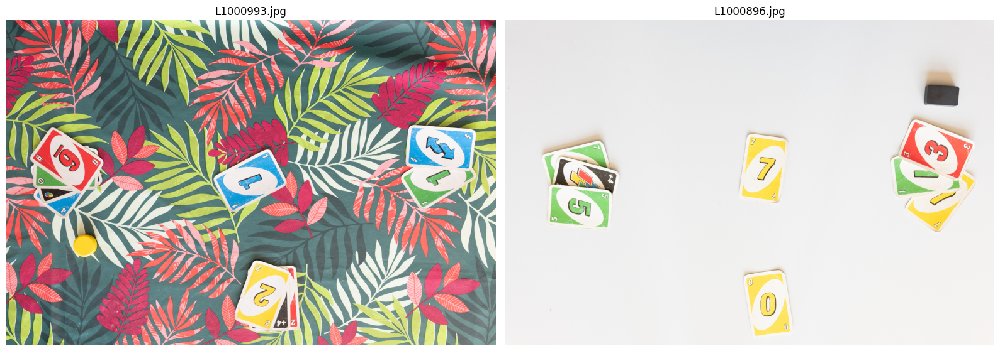

In [2]:
fig, axes = plt.subplots(1, len(demo_images), figsize=(8 * len(demo_images), 6))
axes = np.atleast_1d(axes)

for ax, path, image in zip(axes, DEMO_IMAGE_PATHS, demo_images):
    show_image(image, path.name, ax=ax)

plt.tight_layout()


## Image Type And Token Center

The first decision is which type of active-player token is present. `image_token_type` uses the average image brightness as a simple cue: white-background images are much brighter overall and use the grey token, while colorful-background images are darker overall and use the yellow token.

`get_token_center` then uses a different localization method for each token type. For the yellow token, the pipeline thresholds yellow pixels and looks for a circular component with `find_circle_hough`, because the token is approximately round. For the grey token, the pipeline thresholds the grey HSV range, keeps the largest connected component with `biggest_object`, and returns its centroid with `mask_center`.



L1000993.jpg: detected token type = yellow; token center = (637, 1852)
L1000896.jpg: detected token type = grey; token center = (3570, 622)


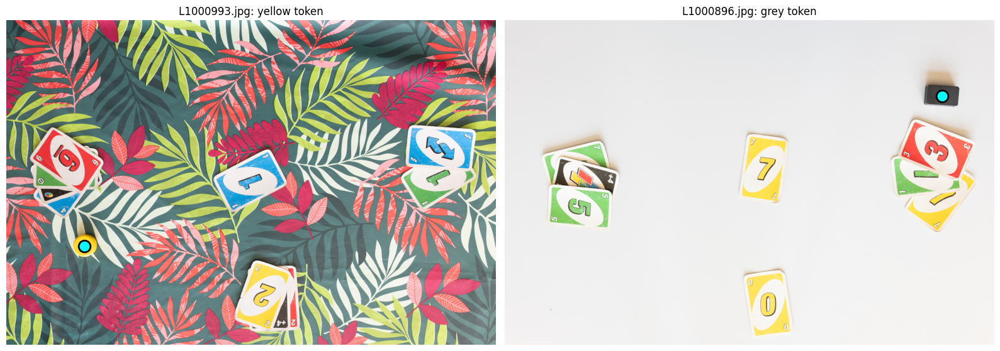

In [3]:
fig, axes = plt.subplots(1, len(demo_images), figsize=(8 * len(demo_images), 6))
axes = np.atleast_1d(axes)

for ax, path, image in zip(axes, DEMO_IMAGE_PATHS, demo_images):
    token = seg.image_token_type(image)
    token_center = seg.get_token_center(image)
    print(f"{path.name}: detected token type = {token}; token center = {token_center}")

    show_image(image, f"{path.name}: {token} token", ax=ax)
    if token_center is not None:
        ax.scatter(*token_center, s=180, c="cyan", edgecolors="black", linewidths=2)

plt.tight_layout()


For the rest of the pipeline demonstration we focus on the first image. The CNN section reuses this same frame, which keeps the intermediate masks, extracted patches, and classified symbols tied to one scene.



## Color Masks

The pipeline starts by separating the image into one binary mask per UNO color: blue, green, red, yellow, black, and white. We decided to do this to exploit the color design of the cards. `get_color_masks` loads the HSV ranges from `hsv_thresholds/`, applies `cv2.inRange` for each configured range, and combines the ranges belonging to the same color. Each of the hsv thresholds defined by the .txt files in the `hsv_thresholds/` were chosen manually on a sample of training images using the `hsv_tuner.py` tool.

HSV is used instead of raw RGB because hue and saturation are more stable under changes in brightness, and allow for easier segmentation of the different colors. After thresholding, each mask is morphologically closed with `morph_close` to fill small gaps, then passed through `min_area_filter` so small components are removed.



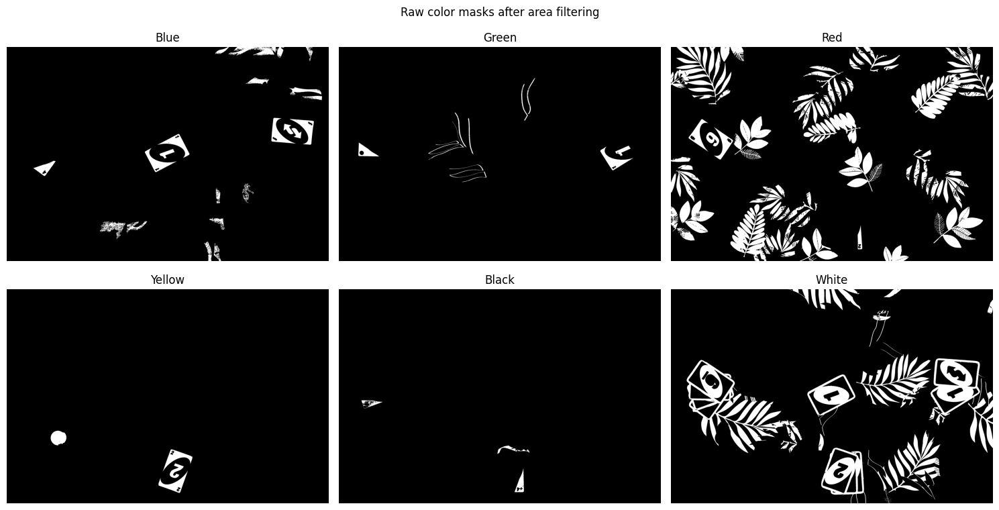

In [4]:
color_masks = seg.get_color_masks(img_color)
show_masks(color_masks, title="Raw color masks after area filtering")


At this point in the pipeline, we can see some card parts as well as a lot of noisy elements, especially from the background. The next steps will focus on refining this segmentation of cards.

## Token Removal

The active-player token can have the same color as objects we care about. On colorful backgrounds the token is yellow, so it may be mistaken for a yellow card region. On white-background images the grey token can overlap with the black mask.

`remove_token_from_color_masks` solves this problem by forcing to 0 pixels from the yellow/black masks, if their coordinates correspond to coordinates of token pixels. 


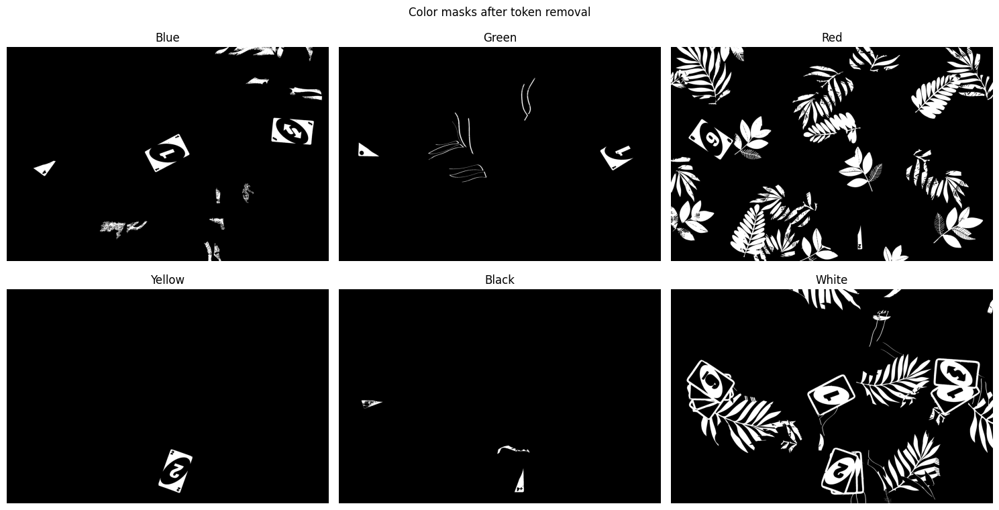

In [5]:
token_removed_masks = seg.remove_token_from_color_masks(
    img_color,
    {color: mask.copy() for color, mask in color_masks.items()},
)
show_masks(token_removed_masks, title="Color masks after token removal")


We can see that the yellow token that previously appeared in the yellow mask has been suppressed and can no longer be mistaken for a card in the rest of the pipeline.

## Keep Card-Like Objects

After color thresholding, a mask may still contain non-card objects: table artifacts, shadows, parts of the token that survived the previous step, or noise that survived the area filter. The UNO cards in these images have a useful structural property: colored card interiors are surrounded by a white border.

`keep_white_surrounded_objects` uses that property to keep only colored components that look card-like. For each object, `keep_objects_surrounded_by_white` builds a ring around the object by dilating it and subtracting the original object. It then measures how much of that ring overlaps the white mask. Components with enough surrounding white are retained; the others are discarded.


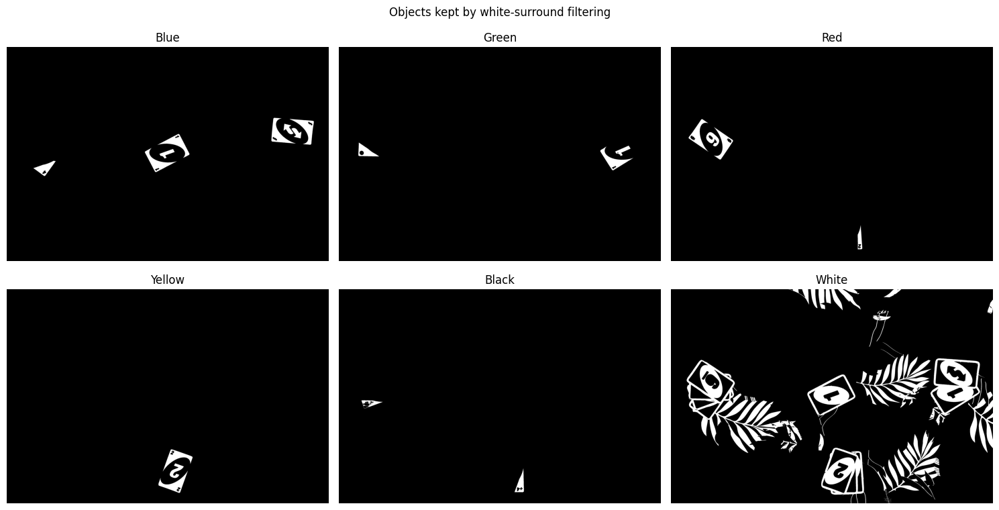

In [6]:
card_masks = seg.keep_white_surrounded_objects(
    {color: mask.copy() for color, mask in token_removed_masks.items()}
)
show_masks(card_masks, title="Objects kept by white-surround filtering")


As we can see, this additional condition for card objects allowed us to remove all the non-card objects from the blue, green, red, yellow, and black masks, which is exactly what we needed for the following steps in the pipeline.

## Holes Inside Card Shapes

Once card-like colored regions are isolated, the next idea is to look for holes inside them. In a binary card mask, white printed symbols appear as missing pixels inside the colored region. `get_holes` fills the exterior background, finds enclosed empty regions, and returns those enclosed regions as candidate symbol pixels.

This step is useful because it turns the symbol search into a shape problem: instead of detecting every possible card symbol directly in RGB space, we first ask which white regions are enclosed by colored cards. The visualization below shows all such enclosed regions before the stricter filtering is applied.



<Axes: title={'center': 'All holes inside colored card regions'}>

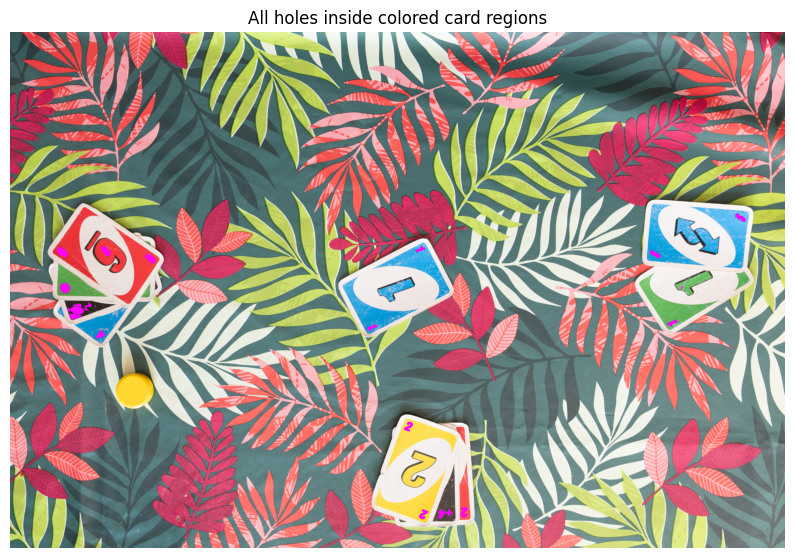

In [7]:
hole_masks = {
    color: seg.get_holes(mask, min_hole_area=100)
    for color, mask in card_masks.items()
    if color != "white"
}
all_holes = np.bitwise_or.reduce(list(hole_masks.values()))
overlay_mask(img_color, all_holes, title="All holes inside colored card regions")


This raw hole-based method is intentionally over-inclusive. Some center symbols contain internal holes themselves, such as `0`, `4`, `6`, `8`, `9`, skip, and `+4`. Those inner holes are not corner symbols, but they are still enclosed by colored pixels, so they appear as candidates.

The next stage filters these candidates using card layout. Corner symbols sit near the white card border, while holes inside the large center symbol remain farther from that border. That spatial difference is what lets us reject many false candidates without needing a classifier yet.



## Filtered Symbol Masks

`extract_symbols_mask_per_color` applies the full symbol-candidate filtering strategy. It starts from the holes found inside each colored card mask, then keeps candidates that are plausible corner symbols.

The key helper is `filter_shapes_by_dilated_ring_overlap_binary`. For each candidate shape, the function dilates the shape and inspects only the newly added ring around it. If that ring overlaps enough white border pixels, the candidate is kept. The dilation radius was selected so that corner symbols are close enough to the card border for their dilation ring to touch white, while false holes inside the central symbol usually stay trapped inside the colored/central-symbol area, even after dilation.

The function also intersects candidates with `white_by_hsv`, a low-saturation mask, to prefer white or near-white symbol pixels and reject colorful artifacts. The result is one cleaned symbol mask per card color.



<Axes: title={'center': 'Final symbol pixels overlaid on the input'}>

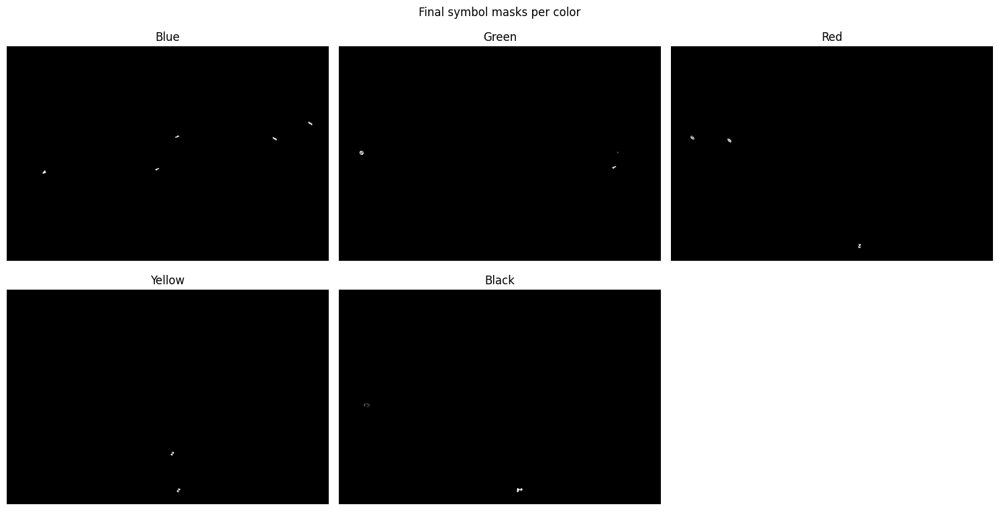

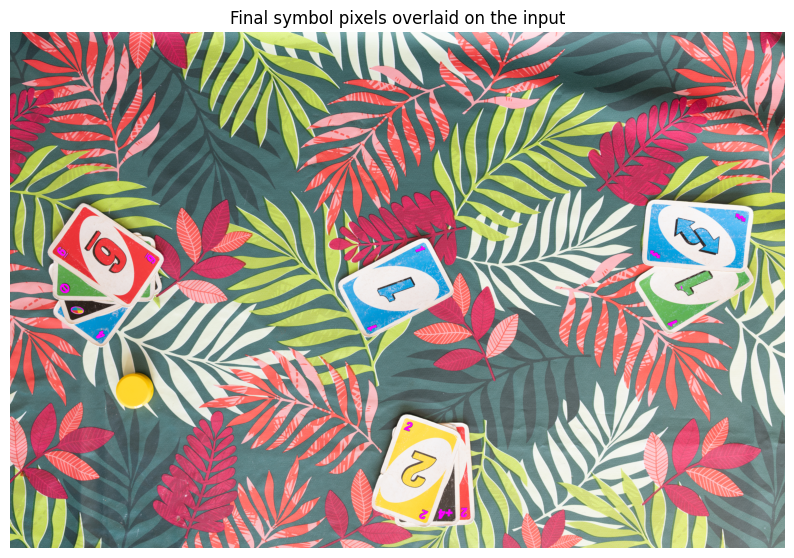

In [8]:
symbols_mask_per_color = seg.extract_symbols_mask_per_color(img_color, card_masks)
total_symbol_mask = np.bitwise_or.reduce(list(symbols_mask_per_color.values()))

show_masks(symbols_mask_per_color, columns=3, title="Final symbol masks per color")
overlay_mask(img_color, total_symbol_mask, title="Final symbol pixels overlaid on the input")


As we can see in the result image, the corner symbols are now perfectly detected while other previous candidates like the holes in the big center 6 and 8 have been ignored.

## Extracted Symbol Patches

The final segmentation output must be usable by the CNN classifier. `detect_symbols` therefore wraps all previous steps and converts the final symbol binary masks into individual records.

Inside it, `extract_merged_symbol_records` merges nearby foreground pixels that belong to the same printed symbol, computes each symbol center in the original image, and calls `crop_centered_binary_mask` to create a fixed-size binary patch around the symbol. We decided to choose 150 pixels by 150 pixels patches so that all symbols can fit, while not wasting too much unused space leading to higher parameters in the CNN. Each returned record contains the patch, the card color, and the image-space center. The classifier later predicts the symbol label from the patch, while the color and center are used to reconstruct the card and assign it to a player or the table.



Detected symbols: 15


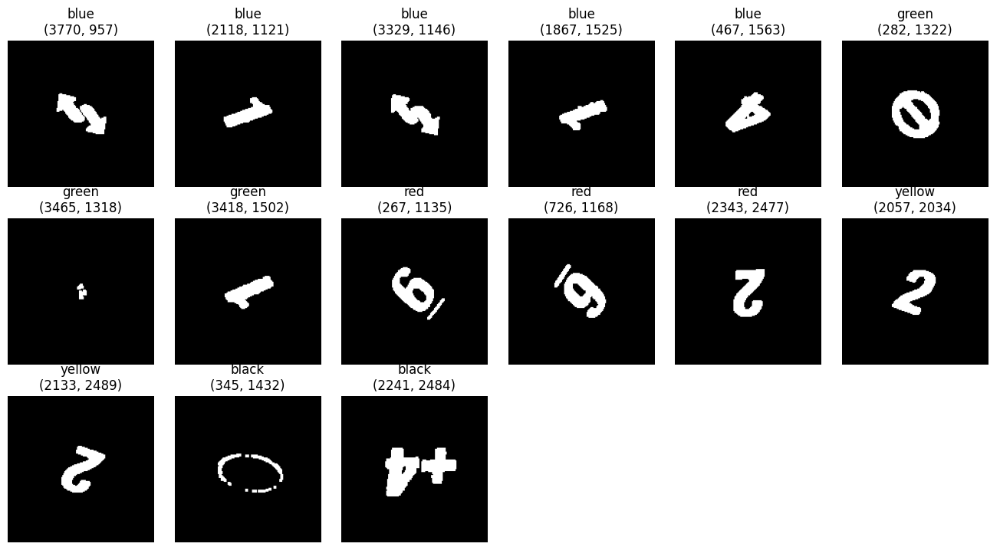

In [9]:
detected_symbols = seg.detect_symbols(img_color)
print(f"Detected symbols: {len(detected_symbols)}")

columns = min(6, max(1, len(detected_symbols)))
rows = int(np.ceil(len(detected_symbols) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(2.2 * columns, 2.4 * rows))
axes = np.atleast_1d(axes).ravel()

for ax, (patch, color, center_xy) in zip(axes, detected_symbols):
    ax.imshow(patch, cmap="gray")
    ax.set_title(f"{color}\n({center_xy[0]:.0f}, {center_xy[1]:.0f})")
    ax.axis("off")

for ax in axes[len(detected_symbols):]:
    ax.axis("off")

plt.tight_layout()


We are now ready to prepare the dataset for classification, but before that let's discuss some edge cases where the segmentation logic fails.

## Segmentation Pipeline Limitations

There are two main types of edge cases where teh segmentation logic fails. The first one is linked to teh filtering of holes in central symbols of cards when detecting corner symbols. The current logic for filtering is that corner symbols are closer to white parts (the edges of the card) compared to the holes of center symbols. Eventhough this logic works on most of the possible images, there exists one edge case where this logic fails. Let's consider a card with a central symbol with a hole. If that card is partially covered by another card so that the hole is still encircled by the card color in te central symbol, but the other card edge is close enough to that hole, then the hole distance to white will be smaller than usual and therefore will pass through the filtering stage. An example of this situation can be seen in this image:

<img src="notebook_images/holes_edge_case.png" height="400">

The other case where segmentation fails is when cards corner symbols are modified by the state of the cards. For example in the next image we can see that the corner symbol is changed by the folding of the card introducing noise which makes later classification much more difficult and unreliable.



# Data Preparation for Classification

## Symbols Dataset Creation

In order to create the dataset of symbols for the CNN classifier, we created the `build_symbol_dataset` script that runs the segmentation pipeline on all images from the training set explained above and saves all symbol patches into one `symbols_dataset` folder, leading to a dataset of approximately 1100 data points.

## Symbols Dataset Labeling

Once the dataset is created, we need to assign them ground truth labels for the classification step. In order to do this, we created a script `dataset_labeling` that offered us an easy-to-use interactive window for manual labeling of each symbol patch. Labels were then saved in a .json file assigning to each patch name its label. The window can be seen in the image:

<img src="notebook_images/labeling_image.jpg" height="500">

As we can see the annotator had the option to delete samples. This was used on samples where the symbol could not be recognized at all and was likely noise, which is impossible to label accurately.

## Data Augmentation for CNN Classification

### Initial classification approach 

Originally, we tried to implement object description and classification using the classical pipeline introduced in class. Following this approach, we first extracted the main outer contours of the detected UNO symbols and computed Fourier descriptors, as demonstrated in Lab 2 for the MNIST dataset. The goal was to obtain a compact, rotation- and translatio-invariant representation of each symbol based on its boundary geometry.

However, we quickly observed that Fourier descriptors based solely on the outer contour were not sufficient for UNO symbols compared to simpler datasets such as MNIST. The main limitation comes from the structural complexity of UNO symbols. Unlike handwritten digits, several symbols are composed of multiple disconnected components. As a result, restricting the representation to a single outer contour leads to a significant loss of discriminative information.

For example, “+2” and “+4” symbols share the same digit shape as “2” and “4”, meaning that by keeping the main outer contour, the "+" sign is lost and they become undistinguishable. Similarly, the digits “6” and “9” cannot be reliably differentiated from the outer contour alone, since their distinguishing feature lies in a small separate stroke that gets ignored with main outer contour extraction. In addition, symbols such as “0”, “8”, “wild”, and “skip” have very similar outer shapes, which leads to frequent misclassifications when relying only on boundary-based descriptors.

A further difficulty arose from the “wild” class itself, where fragmented and inconsistent images from the dataset often resulted in incomplete or unstable contour extraction. This introduced additional noise into the Fourier representation, further degrading classification performance.

To address these issues, we explored extending the feature set beyond Fourier descriptors. We considered incorporating additional features such as the number of outer contours (to distinguish "+2" from "2" for instance), the card background color (to separate "wild" and "+4" cards), and simple geometric descriptors capturing internal structure. However, this led to an increasingly complex pipeline.

### Choice to move to a CNN-based approach

Given these limitations, we ultimately shifted toward a deep learning-based approach using a Convolutional Neural Network (CNN). Unlike handcrafted descriptors, CNNs learn hierarchical feature representations directly from the extracted binary images. In the early layers, they typically detect simple patterns such as edges, corners, and gradients, while deeper layers combine these into more complex structures such as shapes, digits, and symbol-specific configurations. This allows the network to automatically learn discriminative features for each UNO class, including both global shape information and local details (such as the “+” in “+2” or “+4”), without requiring explicit contour engineering. As a result, CNNs provide a more robust and scalable solution for this classification task compared to manually chosen descriptors.

### Need for the augmentation of the dataset as a consequence

Moving to a CNN-based approach required reviewing the dataset preparation. Unlike classical feature-based methods, CNNs are data-driven and require a sufficiently large and diverse training set to generalize well. Since our original dataset was too small, we needed to perform data augmentation to artificially increase its variability. 

#### Number of train images in the augmented dataset
To do so, we chose to aim at having **10 000** images in the training dataset, which meant having roughly **667** images per class with 15 UNO classes. Indeed, below ~500/class, CNNs overfit quickly: the model memorises the training set rather than learning the underlying shape. Above ~1 000/class, gains diminish rapidly for simple binary symbols, and augmentation artefacts start to dominate. Thus, **667** images per class sounded reasonable.

#### Train-validation split
Regarding the train-validation split, we initially used a 90/10 split, which resulted in volatile validation accuracy. This instability was mainly due to the small size of the validation set: with only 10% of the data, the performance estimate had high variance and was overly sensitive to individual samples. Thus, we switched to a 75/25 split, increasing the size of the validation set. This provided a more representative and statistically stable estimate of model performance, while still retaining a sufficient amount of data for training.

With that in mind, the targeted number of images for each set looked like that approximately:

| Split | Per-class target | Total |
|---|---|---|
| **Train** | ~667 | **10 000** |
| **Validation** | ~222 | **3 333** |

#### Augmentation implementation
The original dataset has very few images per class. Augmentation synthetically expands it by applying **random rotation (0–360°)** and **small random translations (±10 px)** to existing images, then **re-binarizing** to preserve the hard black/white look of the originals (bilinear interpolation otherwise produces grey anti-aliasing artefacts). Only the *missing* images needed to reach the target are generated, originals are never duplicated or altered.

### 0 — Imports

**Files used by this notebook**
| File | Role |
|---|---|
| `augmentation_utils.py` | All pipeline functions (I/O, splitting, augmentation, …) |
| `notebook_utils.py` | Visualisation helpers (bar plots, count summaries) |

In [10]:
import os
import matplotlib.pyplot as plt
from PIL import Image

from augmentation_utils import *

from notebook_utils import *

### 1 — Configuration

Here we define the input folder `DATA_DIR` containing the original dataset, created and labeled earlier, and the output folder `OUT_DIR` for the future augmented dataset. The desired total number of training images (`TOTAL_TRAIN`) and the train-validation split (`VAL_RATIO`) are also specified here and can be adjusted if needed.

In [11]:
DATA_DIR   = "symbols_dataset"       # original images + labels.json
OUT_DIR    = "augm_symbols_dataset"  # output folder (created if missing)

TOTAL_TRAIN = 10_000   # desired total training images
VAL_RATIO   = 0.25     # fraction of the full dataset kept for validation

### 2 — Load original labels & compute targets

First, we load the dataset labels from `labels.json` and determine how many different symbol classes are present using `len(set(labels.values()))`. 

The `compute_targets()` function is then used to calculate how many images each class should contain in the training and validation sets in order to create a balanced dataset, where every class has the same number of images. The training target is obtained by dividing the total number of desired training images equally among the classes:

```train_per_class = TOTAL_TRAIN // num_classes```

while the validation target is derived from the specified validation ratio so that the validation set represents approximately the chosen fraction of the complete dataset:

```val_per_class   = train_per_class × VAL_RATIO / (1 − VAL_RATIO)```

In [12]:
labels      = load_json(os.path.join(DATA_DIR, "labels.json"))
num_classes = len(set(labels.values()))

TRAIN_TARGET, VAL_TARGET = compute_targets(
    num_classes=num_classes,
    total_train=TOTAL_TRAIN,
    val_ratio=VAL_RATIO,
)

print(f"Classes detected : {num_classes}")
print(f"Original images  : {len(labels)}")
print()
print(f"Train target  : {TRAIN_TARGET:>5} / class  →  {TRAIN_TARGET * num_classes:>6} total")
print(f"Val   target  : {VAL_TARGET:>5} / class  →  {VAL_TARGET   * num_classes:>6} total")
print(f"Effective val ratio : {VAL_TARGET / (TRAIN_TARGET + VAL_TARGET):.1%}")

Classes detected : 15
Original images  : 1090

Train target  :   666 / class  →    9990 total
Val   target  :   222 / class  →    3330 total
Effective val ratio : 25.0%


The original dataset distribution is given by the bar chart of the symbol counts before splitting and augmentation. We can see that the symbols are present in different quantities in the original dataset, meaning they must be split proportionally to create balanced training and validation sets while preserving the original class distribution.

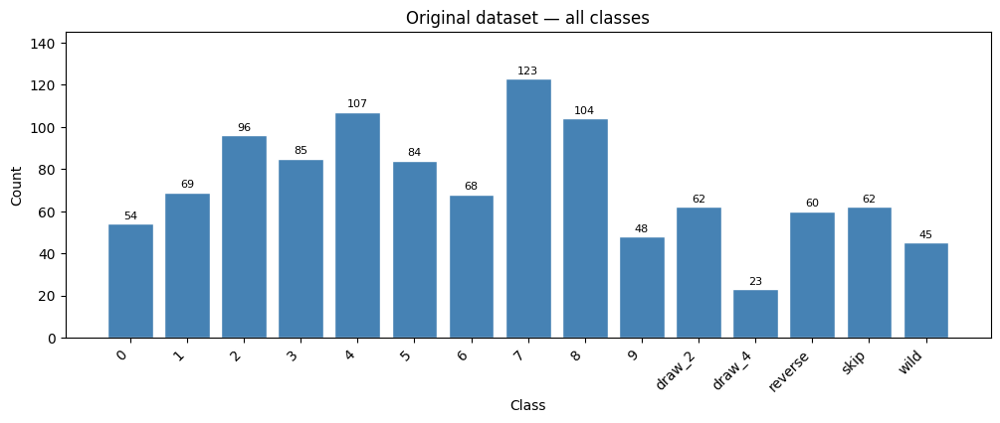

In [13]:
plot_distribution("Original dataset — all classes", labels)
plt.show()

### 3 — Stratified 75/25 train-validation split

Now we split the dataset into training and validation sets while preserving the class distribution. The function `stratified_split()` first groups all images by their class using `group_by_class()`, then shuffles the images within each class to ensure randomness. For each class, a fixed proportion defined by `VAL_RATIO` is assigned to the validation set, while the remaining images are assigned to the training set. The random seed ensures that the split is reproducible. The function returns two dictionaries in the same format as the input, mapping image filenames to their labels.

After the split, `print_split_counts()` displays the number of images per class in both training and validation sets, as well as how these numbers compare to the predefined targets (`TRAIN_TARGET` and `VAL_TARGET`).

In [14]:
train_labels, val_labels = stratified_split(labels, val_ratio=VAL_RATIO, seed=42)

print_split_counts(
    train_labels, val_labels,
    TRAIN_TARGET, VAL_TARGET,
    num_classes,
    stage="Before augmentation (originals only)",
)


──────────────────────────────────────────────  Before augmentation (originals only)
  Split          Images  Expected   OK
  ──────────── ────────  ────────  ───
  Train             822      9990    ✗
  Validation        268      3330    ✗
  TOTAL            1090     13320
──────────────────────────────────────────────


The dataset distribution of the training and validation sets after splitting is displayed below and shows that the images were separated in the right proportions for each symbols.

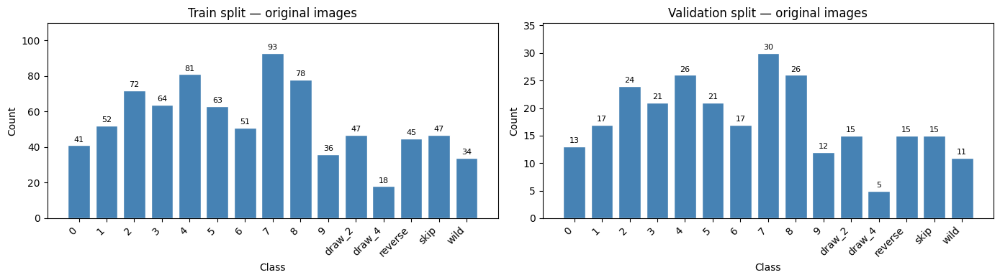

In [15]:
plot_distributions_grid([
    ("Train split — original images", train_labels),
    ("Validation split — original images", val_labels),
])

### 4 — Prepare output folder & copy originals

A safe creation or reuse of an output dataset folder for a stratified image dataset is done with the function `prepare_output_dir()`. It checks whether the output directory already exists and whether it contains both images and the required split files (`train.json` and `val.json`). If the folder is complete, it returns `False`, meaning the pipeline will skip regeneration and simply reload the existing splits from disk. If the folder does not exist, it is created and the function returns `True`, allowing a fresh run. If the folder exists but is incomplete, an error is raised to prevent corrupt or inconsistent datasets from being reused.

If a fresh run is detected, the code saves the initial train/validation splits using `save_json()`, which simply writes Python dictionaries to formatted JSON files. It then copies all original images associated with these splits into the output directory using `copy_images()`, a utility that copies only missing files to avoid duplication. The function `count_files()` is used to count how many image and JSON files exist in both the source and output directories, providing a quick sanity check that the copying step worked correctly. Finally, if the dataset already exists, the script bypasses generation entirely and reloads the saved JSON split files using `load_json()`, ensuring consistency and reproducibility without recomputing or recopying data.

In [16]:
is_fresh_run = prepare_output_dir(OUT_DIR)

if is_fresh_run:
    # Save initial (pre-augmentation) split JSONs
    save_json(train_labels, os.path.join(OUT_DIR, "train.json"))
    save_json(val_labels,   os.path.join(OUT_DIR, "val.json"))

    # Copy original images to output folder
    all_images = list(train_labels.keys()) + list(val_labels.keys())
    copy_images(all_images, src_dir=DATA_DIR, dst_dir=OUT_DIR)

    orig_count, _ = count_files(DATA_DIR)
    out_count,  _ = count_files(OUT_DIR)
    print(f"Original dataset : {orig_count} images")
    print(f"Copied to output : {out_count} images")
else:
    # Folder already complete — reload splits from disk
    train_labels = load_json(os.path.join(OUT_DIR, "train.json"))
    val_labels   = load_json(os.path.join(OUT_DIR, "val.json"))
    print(f"Loaded existing splits — train: {len(train_labels)}, val: {len(val_labels)}")

[INFO] 'augm_symbols_dataset' already contains 13320 images and both split JSONs — skipping generation.
Loaded existing splits — train: 9990, val: 3330


### 5 — Augmentation example

Each training image is augmented using the `augment_image()`. This function applies a **random rotation over the full 360° range**, since symbols observed on cards or a table can appear in any orientation during detection. It also applies a **very small random translation (±10 pixels in both directions)** to account for slight misalignments in the dataset, where symbols are intended to be centered but may be slightly shifted due to shadows, noise, or imperfect extraction.

After these geometric transformations, the image is re-binarized to remove interpolation artefacts introduced by bilinear resampling and to preserve the sharp black-and-white structure of the original symbols. The function additionally returns the applied transformation parameters (rotation angle and translations), which allows each augmented sample to be inspected and verified.

In the example shown, one original image is displayed alongside five augmented versions generated from it. Each augmented sample is annotated with its corresponding transformation values (θ, dx, dy).

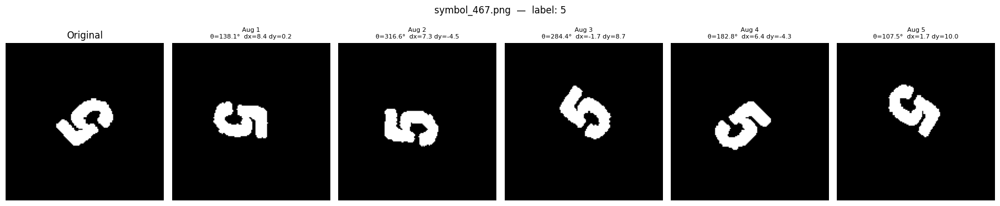

In [17]:
sample_name = list(train_labels.keys())[0]
sample_img  = Image.open(os.path.join(DATA_DIR, sample_name)).convert("RGB")

fig, axes = plt.subplots(1, 6, figsize=(18, 4))

axes[0].imshow(sample_img, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(5):
    aug, angle, tx, ty = augment_image(sample_img)
    axes[i + 1].imshow(aug, cmap="gray")
    axes[i + 1].set_title(f"Aug {i+1}\nθ={angle:.1f}°  dx={tx:.1f} dy={ty:.1f}", fontsize=8)
    axes[i + 1].axis("off")

plt.suptitle(f"{sample_name}  —  label: {train_labels[sample_name]}")
plt.tight_layout()
plt.show()

### 6 — Balance both splits by augmentation

Once the dataset is split into training and validation sets, each split is independently balanced using the `complete_split` function. For each class, the function first counts how many images are already present in the split and computes how many additional samples are required to reach the predefined target. Only these missing samples are generated through augmentation; existing images are never duplicated or modified, ensuring that the original data distribution remains intact.

The function also ensures that all newly generated images use unique filenames by tracking a global index (`start_index`) shared across both splits.

Internally, `complete_split` first groups images by class using `group_by_class`, then iterates through each class to determine how many new samples are needed. For each missing sample, it randomly selects a source image, applies the `augment_image` transformation (rotation + translation), and saves the result to disk. The corresponding label is then added to the updated dictionary, which contains both original and newly generated images. The function returns this updated label set along with the next available index for naming future images, ensuring consistency across the entire dataset generation process.

In [18]:
if is_fresh_run:
    start_idx = next_available_index([train_labels, val_labels])

    new_train, start_idx = complete_split(
        split_labels=train_labels,
        target_count=TRAIN_TARGET,
        src_dir=DATA_DIR,
        out_dir=OUT_DIR,
        start_index=start_idx,
        split_name="TRAIN",
    )

    new_val, _ = complete_split(
        split_labels=val_labels,
        target_count=VAL_TARGET,
        src_dir=DATA_DIR,
        out_dir=OUT_DIR,
        start_index=start_idx,
        split_name="VALIDATION",
    )

    # Overwrite JSONs with the final (augmented) label mappings
    save_json(new_train, os.path.join(OUT_DIR, "train.json"))
    save_json(new_val,   os.path.join(OUT_DIR, "val.json"))
    print("Saved final train.json and val.json")
else:
    new_train = train_labels
    new_val   = val_labels
    print("Augmentation skipped — output folder already complete.")

Augmentation skipped — output folder already complete.


Finally, we check that the expected number of images has been reached for both sets and that the distributions are right thanks to the bar plot. As expected, all symbols have the same distribution within each set.

In [19]:
print_split_counts(
    new_train, new_val,
    TRAIN_TARGET, VAL_TARGET,
    num_classes,
    stage="After augmentation",
)

total_out, _ = count_files(OUT_DIR)
print(f"\nTotal image files in '{OUT_DIR}': {total_out}")


──────────────────────────────────────────────  After augmentation
  Split          Images  Expected   OK
  ──────────── ────────  ────────  ───
  Train            9990      9990    ✓
  Validation       3330      3330    ✓
  TOTAL           13320     13320
──────────────────────────────────────────────

Total image files in 'augm_symbols_dataset': 13320


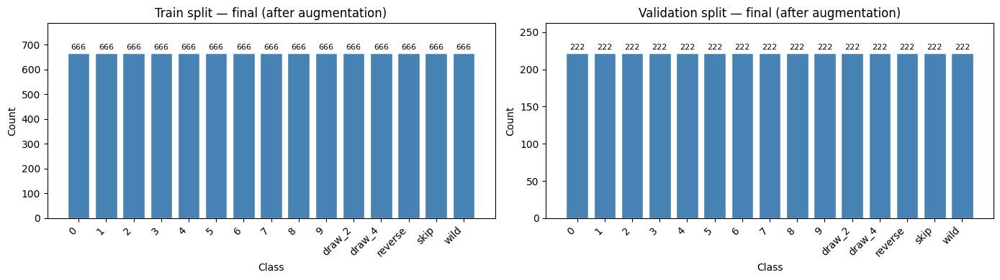

In [20]:
plot_distributions_grid([
    ("Train split — final (after augmentation)", new_train),
    ("Validation split — final (after augmentation)", new_val),
])

We are now ready to train our classifier.

# CNN Classification

The segmentation section produced fixed-size binary symbol patches and kept their color and image-space position. The next part of the pipeline uses a CNN to assign a symbol label to each patch, then combines this label with the detected color to reconstruct UNO cards.


## CNN Architecture Choice

The model used for symbol recognition is `SymbolCNN`. Its input is a single-channel `64 x 64` patch produced by `symbol_transform`, because the extracted symbols are binary shapes.

The feature extractor uses small `3 x 3` convolutions with increasing channel counts (`32 -> 64 -> 128`). Small kernels are a standard choice for local shape recognition: early layers learn simple edges and strokes, while deeper layers combine them into more complete UNO symbols such as numbers, reverse arrows, skips, and wild-card marks. `BatchNorm2d` stabilizes training, `ReLU` adds non-linearity, and `MaxPool2d` gradually reduces spatial resolution while keeping the strongest local features.

The network is intentionally compact. The dataset contains simple high-contrast symbols, so a very deep architecture would be unnecessary and more likely to overfit augmented artifacts. The `Dropout2d` and final `Dropout` layers add regularization, while `AdaptiveAvgPool2d((1, 1))` replaces a large fully connected head with a global summary of the learned feature maps. The final `Linear(128, num_classes)` layer then maps this compact representation to the symbol classes.


In [21]:
model_path, history_path, history, trained_now = ensure_model(
    model_path=MODEL_PATH,
    history_path=HISTORY_PATH,
    device='auto',
    parameter_count=True
)


if not trained_now:
    print('The model was already trained in a previous run')


SymbolCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1,

## CNN Performance on the Symbol Dataset

Before applying the CNN to a full frame, we evaluate it on the validation split created during data preparation. `evaluate_model` uses `load_model` and `SymbolDataset` from the CNN module to load the saved weights and validation images, then runs the model without shuffling so predictions can be accumulated into a confusion matrix.

The validation split is held out from training, so it gives a first estimate of how well the CNN generalizes to unseen augmented patches. Accuracy measures the global fraction of correct predictions, while the F1 score summarizes precision and recall. `plot_confusion_matrix` then shows the class-by-class behavior, which is useful because two symbols could have a high global accuracy while still being confused with each other.


In [22]:
metrics, confusion_matrix, idx_to_class = evaluate_model(model_path=MODEL_PATH, device='auto')
metrics


{'accuracy': 1.0, 'f1': 1.0}

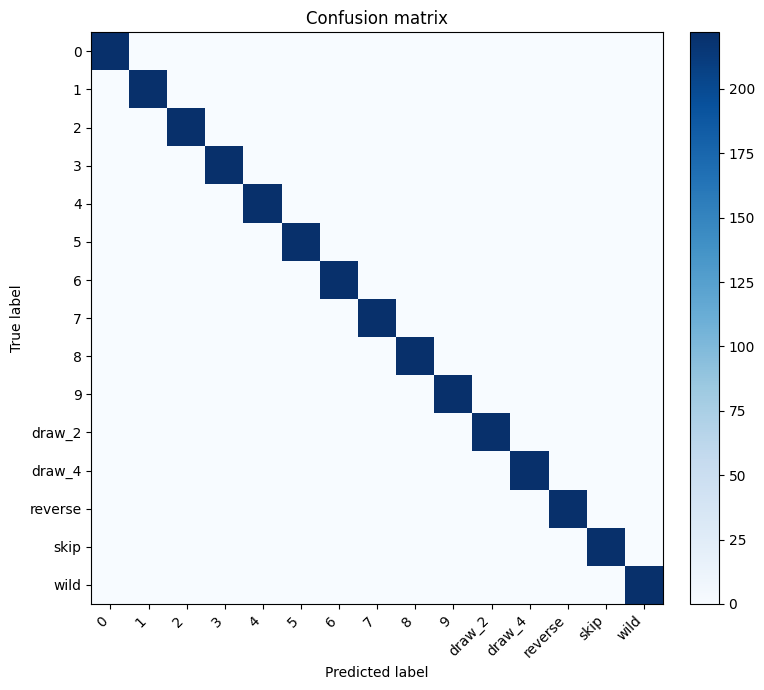

In [23]:
plot_confusion_matrix(confusion_matrix, idx_to_class)
plt.show()


### Performance Analysis

The validation accuracy and F1 score are both equal to `1.0`, which indicates that the CNN correctly classifies every symbol patch in the validation split. 

The confusion matrix supports this result: the predictions lie on the diagonal, meaning that no class is visibly confused with another class. For this dataset, the augmentation strategy seems sufficient to make the model robust to rotation and small shifts in the extracted binary patches.

This result should still be interpreted with the dataset construction in mind. The validation images come from the same symbol-extraction and augmentation process as the training data, so the CNN result mainly validates the symbol classifier once a clean patch has been extracted. In the full image pipeline, errors are more likely to come from segmentation, card grouping, or player attribution than from the CNN itself.


### Training Curves

The following plot displays the training and validation accuracy/loss over epochs. The technique here is to compare optimization on the training set with generalization on the validation set: both accuracies should improve, both losses should generally decrease, and the validation curve should not drift away from the training curve.

This gives a visual check for underfitting, overfitting, or unstable training that would not be visible from the final accuracy alone.


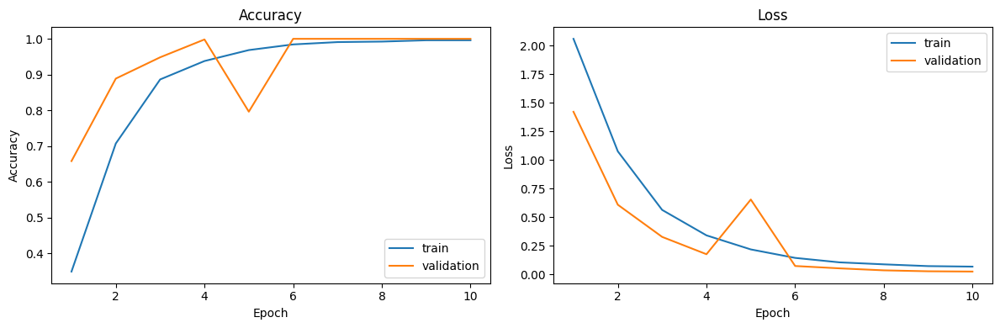

In [24]:
plot_history(history)
plt.show()


The curves show that the CNN learns the symbol shapes very quickly. Training accuracy rises from about `0.35` in the first epoch to almost `1.0` by the end, while the training loss decreases steadily across all epochs. This indicates that the model is able to fit the augmented symbol dataset without difficulty.

The validation curve follows the same general trend and reaches `1.0` accuracy from epoch 6 onward. There is one visible instability around epoch 5, where validation loss increases and validation accuracy drops, but the model recovers immediately in the next epoch. Since the validation performance then stays perfect while the loss continues decreasing, this looks like a temporary optimization fluctuation rather than persistent overfitting.

Overall, the training curves are consistent with the final validation metrics: the CNN has converged, and the classification task is well solved once the segmentation pipeline provides clean binary symbol patches.


## CNN Inference

The CNN only predicts the symbol shape, not the full UNO card. The full card label is reconstructed afterwards with `card_string`, which combines the segmented card color with the predicted symbol. This separation is useful because color is easier to obtain from classical segmentation, while the CNN focuses on recognizing the symbol shape despite rotation and small translations.

Each displayed patch corresponds to one detected corner symbol. The title shows the reconstructed card label followed by the prediction confidence. At this stage the pipeline has one classified card candidate per detected symbol.


Example frame: L1000993.jpg


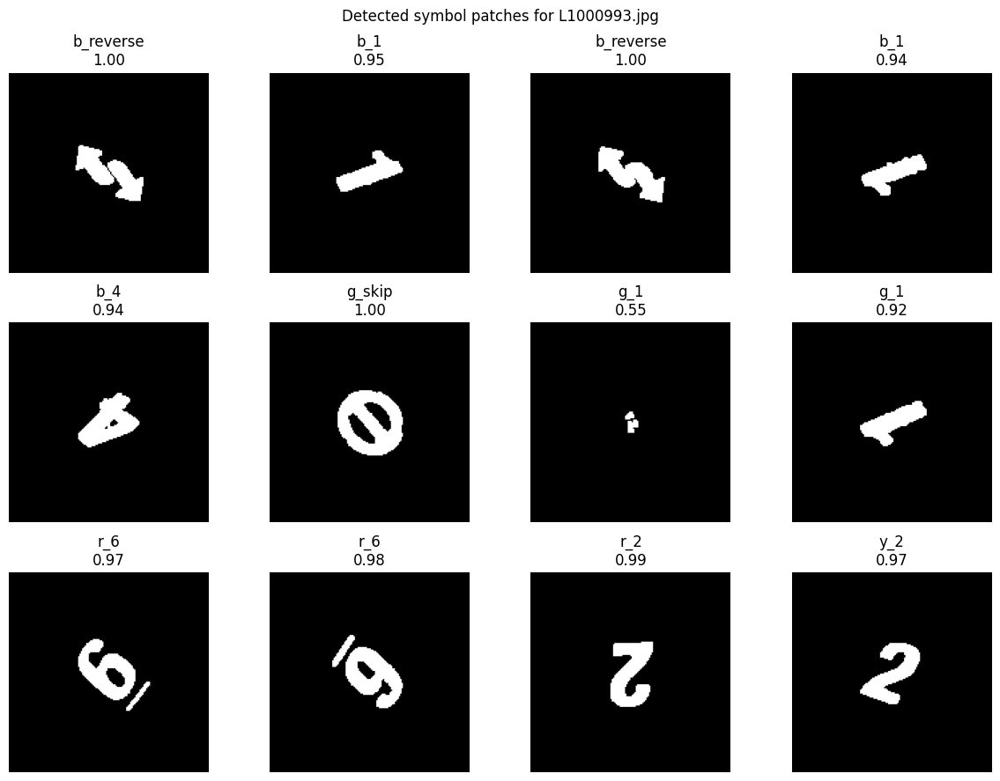

In [25]:
classifier = Classifier(MODEL_PATH, device='auto')
example_frame = IMAGE_PATH
print('Example frame:', example_frame.name)
debug_example = show_patch_predictions(example_frame, classifier)
plt.show()


As we can see all symbols are correctly detected and with high confidence.

# Center Card, Player Card, and Token Attribution


## Cards attribution

Once the symbols have been classified, `assign_players` attributes each detected card to either the center pile or one of the four players. The logic uses geometry: the detections closest to the image center are treated as center-pile candidates, because the played card is expected to be near the middle of the table.

The remaining detections are player-hand candidates. In order to assign each card to their player `assign_players` first clusters the symbols with `cluster_points`. To do this, we use the DBSCAN clustering algorithm which clusters together symbols that are closer than a maximum distance. This distance was manually selected based on the training images structure. Once each card has been assigned to a cluster the cluster centroid is computed and will be used to find which player the cluster of symbols belongs to. `cluster_2_player_mapping` maps the resulting clusters to the four player anchor regions around the image. These regions were defined as the center of the corresponding side of the image with a small offset towards the center of the image.

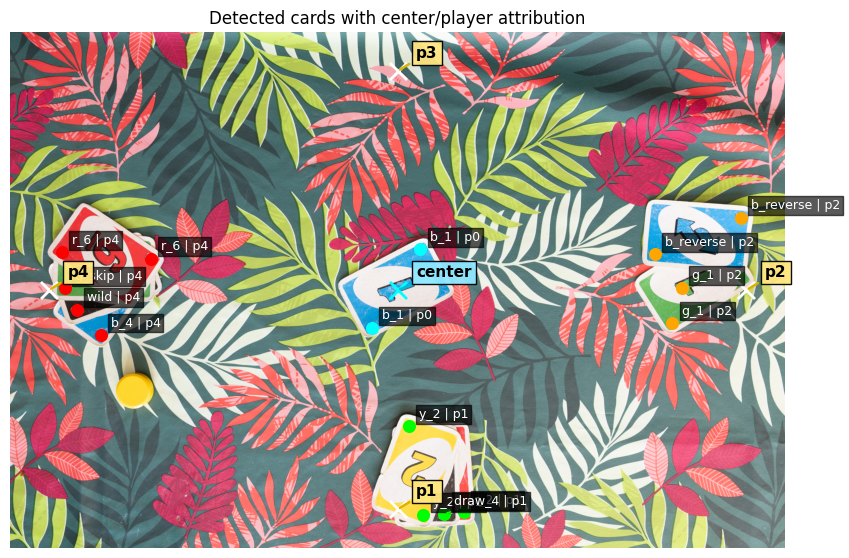

{'image_id': 'L1000993',
 'center_card': 'b_1',
 'active_player': 'p4',
 'player_1_cards': 'y_2;draw_4;r_2',
 'player_2_cards': 'b_reverse;g_1;g_1',
 'player_3_cards': 'EMPTY',
 'player_4_cards': 'r_6;g_skip;wild;b_4'}

In [26]:
show_pipeline_assignments(debug_example, show_image=True, remove_duplicates=False, show_anchors=True)
plt.show()
debug_example['row']


As we can see, each indiviual symbol is assigned to a player. However, we still have duplicates due to the fact that each card, when seen entirely, has two corner symbols. Therefore, to accurately represent the cards from each player, we need to find a way to remove these duplicates

## Duplicate Card Detection Removal

The segmentation can sometimes detect the two printed corner symbols of the same physical card as two separate card detections. This is expected because each UNO card has repeated corner symbols, and both can pass the symbol filter.

After cards have been assigned to players, `sort_player_cards` orders each player's detections in reading order. `collapse_duplicate_detections` then groups detections with the same card label and compares the distance between their centers. If two same-label detections are separated by the expected corner-symbol distance, the second one is removed, because the pair is interpreted as one physical card rather than two identical cards. Implementing the distance check before deletion ensures that if teh player actually has two of the same card, one of the cards is not ignored.


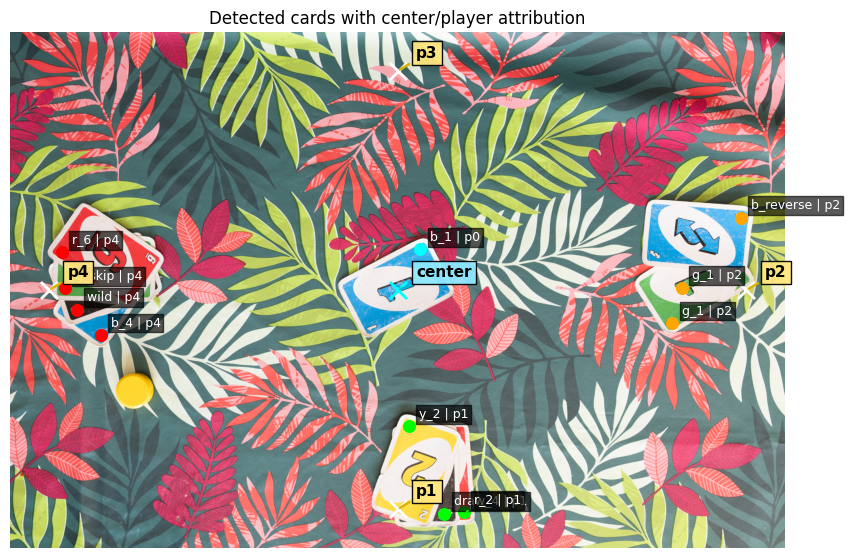

Player 1
  before: ['y_2', 'y_2', 'draw_4', 'r_2']
  after:  ['y_2', 'draw_4', 'r_2']
Player 2
  before: ['b_reverse', 'b_reverse', 'g_1', 'g_1']
  after:  ['b_reverse', 'g_1', 'g_1']
Player 3
  before: ['EMPTY']
  after:  ['EMPTY']
Player 4
  before: ['r_6', 'r_6', 'g_skip', 'wild', 'b_4']
  after:  ['r_6', 'g_skip', 'wild', 'b_4']


In [27]:
show_pipeline_assignments(debug_example, show_image=True, remove_duplicates=True)
plt.show()
show_duplicate_collapse(debug_example)


As we can see, duplicates are removed and the player hands are now accurate.

## Token Attribution

The active-player token is detected separately by the segmentation pipeline with `segmentation.get_token_center`. The logic is again geometric: `active_player_from_token` defines four anchor positions around the image, one for each player, and assigns the token to the nearest anchor by Euclidean distance.

`show_token_assignment` displays the token center and the anchor positions so the decision can be inspected visually. This step is independent of the card labels: the CNN identifies what cards are present, while the token position identifies which player is active.


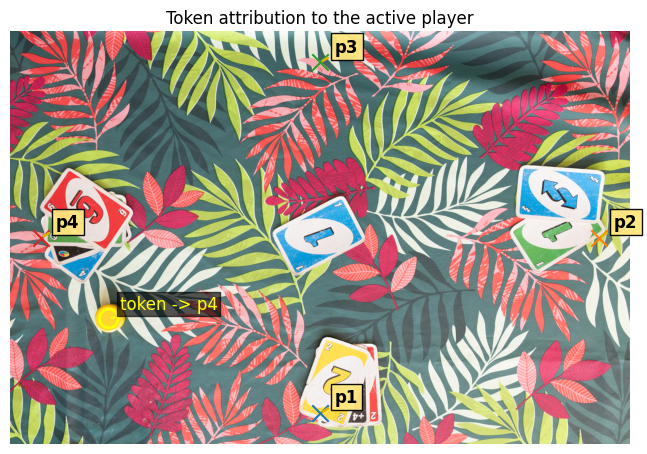

Active player: p4


In [28]:
show_token_assignment(debug_example)
plt.show()
print('Active player:', debug_example['active_player'])

# Full Pipeline Output

Here is the result of the prediction of the demonstration image selected from the testing set:


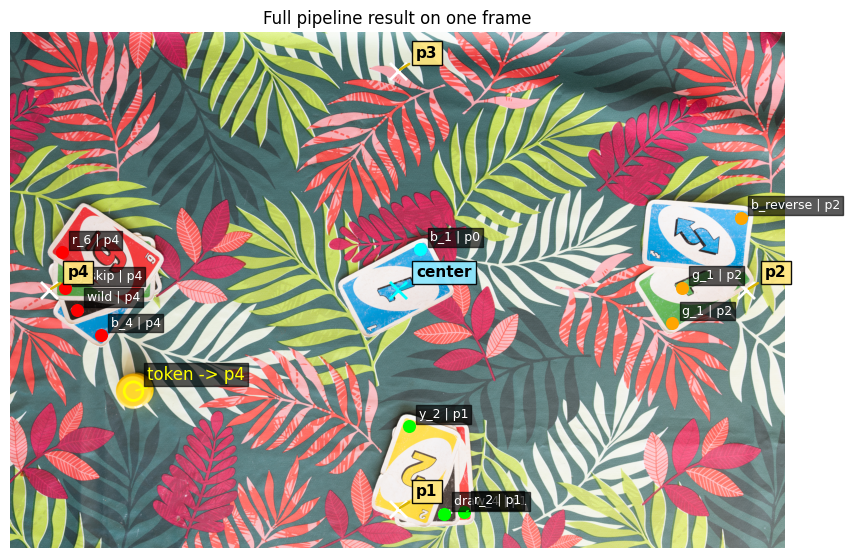

{'image_id': 'L1000993',
 'center_card': 'b_1',
 'active_player': 'p4',
 'player_1_cards': 'y_2;draw_4;r_2',
 'player_2_cards': 'b_reverse;g_1;g_1',
 'player_3_cards': 'EMPTY',
 'player_4_cards': 'r_6;g_skip;wild;b_4'}

In [29]:
full_debug = build_pipeline_debug(example_frame, classifier)
show_full_pipeline_frame(full_debug, remove_duplicates=True)
plt.show()
full_debug['row']


# Conclusion

This project proposes a complete computer vision pipeline for analyzing UNO game images. Each part of the pipeline contributes to transforming a raw game image into a structured prediction containing the center card, the active player, and the cards assigned to each player. The results show that this modular approach is effective for the provided dataset, especially because the intermediate visualizations make it possible to inspect and understand the decisions made at each step.

The project also highlights the difficulty of building a robust pipeline for real images. For this reason, the final method relies not only on classification accuracy, but also on several post-processing steps that use the spatial organization of the scene. These logic-based corrections make the predictions more consistent and help adapt the raw detections to the structure of an UNO game.

Several improvements could be developed in future work. A first direction would be to make the pipeline more general by reducing assumptions about the image, for example by detecting the active-player token directly instead of relying on grayscale-level information to decide what kind of token to search for. Another important improvement would be to revisit the segmentation stage and add logic fixes to make it more robust to the edge cases discussed during the project.

Overall, the project demonstrates that combining computer vision techniques with game-specific reasoning can produce meaningful and interpretable predictions, while also leaving clear opportunities for future refinement.